In [1]:
import sys
print(sys.executable)


/home/leesungwon/miniconda3/envs/eda/bin/python


In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

# padded p90 dataset을 우선 로드합니다. padding 이전 실제 길이는 seq_len으로 따로 관리합니다.
DATASETS = {
    'mininet': [
        Path('../dataset_mininet_merged_padded_p90.jsonl'),
        Path('dataset_mininet_merged_padded_p90.jsonl'),
        Path('../dataset_mininet_merged_p90.jsonl'),
        Path('dataset_mininet_merged_p90.jsonl'),
        Path('../dataset_mininet_merged.jsonl'),
        Path('dataset_mininet_merged.jsonl'),
        Path('../dataset.jsonl'),
        Path('dataset.jsonl'),
        Path('model/dataset.jsonl'),
        Path('../model/dataset.jsonl'),
    ],
    'univ1': [
        Path('../dataset_univ1_padded_p90.jsonl'),
        Path('dataset_univ1_padded_p90.jsonl'),
        Path('../dataset_univ1_p90.jsonl'),
        Path('dataset_univ1_p90.jsonl'),
        Path('../dataset_univ1.jsonl'),
        Path('dataset_univ1.jsonl'),
        Path('model/dataset_univ1.jsonl'),
    ],
}

FEATURE_NAMES = [
    'frame_len',
    'ip_len',
    'ip_ttl',
    'tcp_payload_bytes',
    'tcp_flags',
    'tcp_window_size',
    'iat_us',
    'retransmission',
    'out_of_order',
    'duplicate_ack',
    'fast_retransmission',
]

MASKED_FEATURES = [
    'retransmission',
    'out_of_order',
    'duplicate_ack',
    'fast_retransmission',
]


def resolve_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('dataset jsonl 파일을 찾지 못했습니다: ' + ', '.join(map(str, candidates)))


def clamp_seq_len(sample, x):
    raw_seq_len = int(sample.get('seq_len', x.shape[0]))
    return max(1, min(raw_seq_len, x.shape[0]))


def load_flow_dataset(path, dataset_name):
    meta_rows = []
    packet_rows = []

    with Path(path).open('r', encoding='utf-8') as f:
        for row_id, line in enumerate(f, start=1):
            if not line.strip():
                continue

            sample = json.loads(line)
            flow_key = sample.get('flow_key', {})
            trace_key = sample.get('trace_key', {})
            x = np.asarray(sample.get('x', []), dtype=float)

            if x.ndim != 2 or x.shape[1] != len(FEATURE_NAMES):
                raise ValueError(f'{path}:{row_id} x shape이 예상과 다릅니다: {x.shape}')

            seq_len = clamp_seq_len(sample, x)
            valid_x = x[:seq_len]
            src_index = flow_key.get('src_index', 0)
            flow_id = flow_key.get('flow_id', flow_key.get('tcp_stream', row_id))
            source_file = flow_key.get('source_file', trace_key.get('source_file', ''))
            tcp_stream = flow_key.get('tcp_stream', trace_key.get('tcp_stream', np.nan))
            direction = flow_key.get('direction', '')
            run_id = sample.get('run_id', '')
            directional_size = sample.get('directional_size_bytes', 0)
            flow_size = sample.get('flow_size_bytes', directional_size)
            label = sample.get('label')

            tcp_payload = valid_x[:, FEATURE_NAMES.index('tcp_payload_bytes')]
            iat = valid_x[:, FEATURE_NAMES.index('iat_us')]
            tcp_flags = valid_x[:, FEATURE_NAMES.index('tcp_flags')]

            meta = {
                'dataset': dataset_name,
                'row_id': row_id,
                'run_id': run_id,
                'src_index': src_index,
                'flow_id': flow_id,
                'source_file': source_file,
                'tcp_stream': tcp_stream,
                'direction': direction,
                'direction_label': f'{direction} L{label}',
                'directional_size_bytes': directional_size,
                'flow_size_bytes': flow_size,
                'label': label,
                'packet_count': x.shape[0],
                'seq_len': seq_len,
                'padded_packet_count': int(x.shape[0] - seq_len),
                'is_padded_sample': int(seq_len < x.shape[0]),
                'x_mean': float(valid_x.mean()),
                'cum_payload_10': float(tcp_payload.sum()),
                'payload_packet_count_10': int((tcp_payload > 0).sum()),
                'full_payload_packet_count_10': int((tcp_payload >= 1400).sum()),
                'elapsed_iat_us_10': float(iat.sum()),
                'mean_iat_us_10': float(iat.mean()),
                'max_iat_us_10': float(iat.max()),
                'seen_fin_10': int(((tcp_flags.astype(int) & 0x01) > 0).any()),
                'seen_rst_10': int(((tcp_flags.astype(int) & 0x04) > 0).any()),
            }

            for col_idx, feature_name in enumerate(FEATURE_NAMES):
                values = valid_x[:, col_idx]
                meta[f'{feature_name}_mean'] = float(values.mean())
                meta[f'{feature_name}_first'] = float(values[0])
                meta[f'{feature_name}_last'] = float(values[-1])
                meta[f'{feature_name}_max'] = float(values.max())

            meta_rows.append(meta)

            for packet_index, values in enumerate(x):
                packet_row = {
                    'dataset': dataset_name,
                    'row_id': row_id,
                    'run_id': run_id,
                    'flow_id': flow_id,
                    'source_file': source_file,
                    'tcp_stream': tcp_stream,
                    'direction': direction,
                    'direction_label': f'{direction} L{label}',
                    'packet_index': packet_index,
                    'seq_len': seq_len,
                    'is_padding': packet_index >= seq_len,
                    'label': label,
                    'flow_size_bytes': flow_size,
                    'directional_size_bytes': directional_size,
                }
                packet_row.update(dict(zip(FEATURE_NAMES, values)))
                packet_rows.append(packet_row)

    return pd.DataFrame(meta_rows), pd.DataFrame(packet_rows)


loaded = {}
flow_frames = []
packet_frames = []

for dataset_name, candidates in DATASETS.items():
    dataset_path = resolve_path(candidates)
    flow_df, flow_packet_df = load_flow_dataset(dataset_path, dataset_name)
    loaded[dataset_name] = dataset_path
    flow_frames.append(flow_df)
    packet_frames.append(flow_packet_df)

all_df = pd.concat(flow_frames, ignore_index=True)
all_packet_df = pd.concat(packet_frames, ignore_index=True)
valid_packet_df = all_packet_df[~all_packet_df['is_padding']].copy()
padding_packet_df = all_packet_df[all_packet_df['is_padding']].copy()

mininet_df = all_df[all_df['dataset'] == 'mininet'].copy()
univ1_df = all_df[all_df['dataset'] == 'univ1'].copy()
mininet_packet_df = valid_packet_df[valid_packet_df['dataset'] == 'mininet'].copy()
univ1_packet_df = valid_packet_df[valid_packet_df['dataset'] == 'univ1'].copy()

print('loaded paths:')
for name, dataset_path in loaded.items():
    print(f'- {name}: {dataset_path}')

print('')
print('flow counts by dataset/label:')
print(all_df.groupby(['dataset', 'label']).size())
print('')
print('flow counts by dataset/direction/label:')
print(all_df.groupby(['dataset', 'direction', 'label']).size())

valid_masked_nonzero = valid_packet_df[MASKED_FEATURES].to_numpy().sum()
padding_masked_nonzero = padding_packet_df[MASKED_FEATURES].to_numpy().sum() if len(padding_packet_df) else 0
print(f'\nvalid masked feature nonzero sum: {valid_masked_nonzero:g}')
print(f'padding masked feature nonzero sum: {padding_masked_nonzero:g}')

summary_cols = ['seq_len', 'padded_packet_count', 'flow_size_bytes', 'directional_size_bytes', 'cum_payload_10', 'elapsed_iat_us_10']
display(all_df.groupby('dataset')[summary_cols].agg(['count', 'mean', 'median', 'min', 'max']))
display(all_df.head())


loaded paths:
- mininet: ../dataset_mininet_merged_padded_p90.jsonl
- univ1: ../dataset_univ1_padded_p90.jsonl

flow counts by dataset/label:
dataset  label
mininet  0         28799
         1          3201
univ1    0        263966
         1         29331
dtype: int64

flow counts by dataset/direction/label:
dataset  direction   label
mininet  dst_to_src  0         12799
                     1          3201
         src_to_dst  0         16000
univ1    dst_to_src  0        119541
                     1         25982
         src_to_dst  0        144425
                     1          3349
dtype: int64

valid masked feature nonzero sum: 0
padding masked feature nonzero sum: 0


seq_len                          padded_packet_count                   \
          count      mean median min max               count      mean median   
dataset                                                                         
mininet   32000  5.840969    5.0   2  10               32000  4.159031    5.0   
univ1    293297  7.732302    8.0   1  10              293297  2.267698    2.0   

                 ... cum_payload_10                                     \
        min max  ...          count         mean median   min      max   
dataset          ...                                                     
mininet   0   8  ...          32000  3213.110312   21.0  20.0  13052.0   
univ1     0   9  ...         293297  2720.256290  982.0   0.0  14600.0   

        elapsed_iat_us_10                                            
                    count          mean    median  min          max  
dataset                                                              
mininet             32000  1.174799e+04    1215.0  1.0     335912.0  
univ1              293297  4.064688e+06  307437.0  0.0  350939878.0  

[2 rows x 30 columns]

,dataset,row_id,run_id,src_index,flow_id,source_file,tcp_stream,direction,direction_label,directional_size_bytes,...,out_of_order_last,out_of_order_max,duplicate_ack_mean,duplicate_ack_first,duplicate_ack_last,duplicate_ack_max,fast_retransmission_mean,fast_retransmission_first,fast_retransmission_last,fast_retransmission_max
0,mininet,1,mininet_001,0,1,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,mininet,2,mininet_001,0,2,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,mininet,3,mininet_001,0,3,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,mininet,4,mininet_001,0,4,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,mininet,5,mininet_001,0,5,,NaN,src_to_dst,src_to_dst L0,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Padded dataset / seq_len-aware feature sanity checks
print('dataset files:')
for name, path in loaded.items():
    print(f'- {name}: {path}')

print('\nshape and seq_len checks:')
shape_summary = all_df.groupby('dataset').agg(
    samples=('row_id', 'count'),
    fixed_packet_count_min=('packet_count', 'min'),
    fixed_packet_count_max=('packet_count', 'max'),
    seq_len_min=('seq_len', 'min'),
    seq_len_median=('seq_len', 'median'),
    seq_len_mean=('seq_len', 'mean'),
    seq_len_max=('seq_len', 'max'),
    padded_sample_rate=('is_padded_sample', 'mean'),
)
display(shape_summary)

bad_seq = all_df[(all_df['seq_len'] < 1) | (all_df['seq_len'] > all_df['packet_count'])]
print(f'bad seq_len rows: {len(bad_seq)}')

print('\nseq_len distribution by dataset/label:')
display(
    all_df
    .groupby(['dataset', 'label', 'seq_len'])
    .size()
    .rename('count')
    .reset_index()
    .pivot_table(index=['dataset', 'label'], columns='seq_len', values='count', fill_value=0)
)

print('\nNaN / inf checks on valid packets only:')
valid_values = valid_packet_df[FEATURE_NAMES].to_numpy(dtype=float)
print('nan count:', int(np.isnan(valid_values).sum()))
print('inf count:', int(np.isinf(valid_values).sum()))

print('\nfeature zero-rate on valid packets:')
zero_rate = (
    valid_packet_df
    .groupby('dataset')[FEATURE_NAMES]
    .agg(lambda s: float((s == 0).mean()))
    .T
    .sort_index()
)
display(zero_rate)

print('\nflow_size duplicate / concentration check:')
dup_rows = []
for dataset_name, df in all_df.groupby('dataset'):
    counts = df['flow_size_bytes'].value_counts()
    dup_rows.append({
        'dataset': dataset_name,
        'samples': len(df),
        'unique_flow_size_bytes': int(counts.size),
        'duplicate_sample_rate': float(1 - counts.size / len(df)),
        'top_size_count': int(counts.iloc[0]),
        'top_size_ratio': float(counts.iloc[0] / len(df)),
        'top_size_bytes': float(counts.index[0]),
    })
display(pd.DataFrame(dup_rows))

print('\ntop repeated flow_size_bytes by dataset:')
for dataset_name, df in all_df.groupby('dataset'):
    print(f'[{dataset_name}]')
    display(df['flow_size_bytes'].value_counts().head(10).rename_axis('flow_size_bytes').reset_index(name='count'))

print('\nUNI1 vs Mininet feature domain gap, valid packets only:')
feature_domain = valid_packet_df.groupby('dataset')[FEATURE_NAMES].agg(['mean', 'median', 'std', 'min', 'max'])
display(feature_domain)


dataset files:
- mininet: ../dataset_mininet_merged_padded_p90.jsonl
- univ1: ../dataset_univ1_padded_p90.jsonl

shape and seq_len checks:


,samples,fixed_packet_count_min,fixed_packet_count_max,seq_len_min,seq_len_median,seq_len_mean,seq_len_max,padded_sample_rate
dataset,,,,,,,,
mininet,32000,10,10,2,5.0,5.840969,10,0.695719
univ1,293297,10,10,1,8.0,7.732302,10,0.594022


bad seq_len rows: 0

seq_len distribution by dataset/label:


seq_len            1       2       3        4        5        6        7   \
dataset label                                                               
mininet 0         0.0  6925.0  6214.0   2418.0   1759.0   1177.0    838.0   
        1         0.0     0.0     0.0      0.0      0.0      0.0      0.0   
univ1   0      1613.0  4787.0  2558.0  12601.0  37852.0  45723.0  25932.0   
        1         0.0     0.0     0.0      0.0      0.0      0.0      0.0   

seq_len             8        9        10  
dataset label                             
mininet 0        734.0   2198.0   6536.0  
        1          0.0      0.0   3201.0  
univ1   0      25677.0  17482.0  89741.0  
        1          0.0      0.0  29331.0


NaN / inf checks on valid packets only:
nan count: 0
inf count: 0

feature zero-rate on valid packets:


...

,flow_size_bytes,count
0,20,15950
1,40,50
2,22,45
3,25,36
4,23,31
5,21,28
6,24,21
7,789,15
8,910,15
9,776,14


[univ1]


,flow_size_bytes,count
0,308,4089
1,307,4018
2,317,3906
3,85,2345
4,304,2027
5,0,1901
6,315,1900
7,354,1896
8,6,1878
9,352,1872



UNI1 vs Mininet feature domain gap, valid packets only:


frame_len                                       ip_len         \
               mean median         std   min     max        mean median   
dataset                                                                   
mininet  616.101824   86.0  681.091572  66.0  1514.0  602.101824   72.0   
univ1    415.125577   70.0  545.104373  64.0  1518.0  394.805876   52.0   

                                   ... duplicate_ack                        \
                std   min     max  ...          mean median  std  min  max   
dataset                            ...                                       
mininet  681.091572  52.0  1500.0  ...           0.0    0.0  0.0  0.0  0.0   
univ1    546.604253  40.0  1500.0  ...           0.0    0.0  0.0  0.0  0.0   

        fast_retransmission                        
                       mean median  std  min  max  
dataset                                            
mininet                 0.0    0.0  0.0  0.0  0.0  
univ1                   0.0    0.0  0.0  0.0  0.0  

[2 rows x 55 columns]

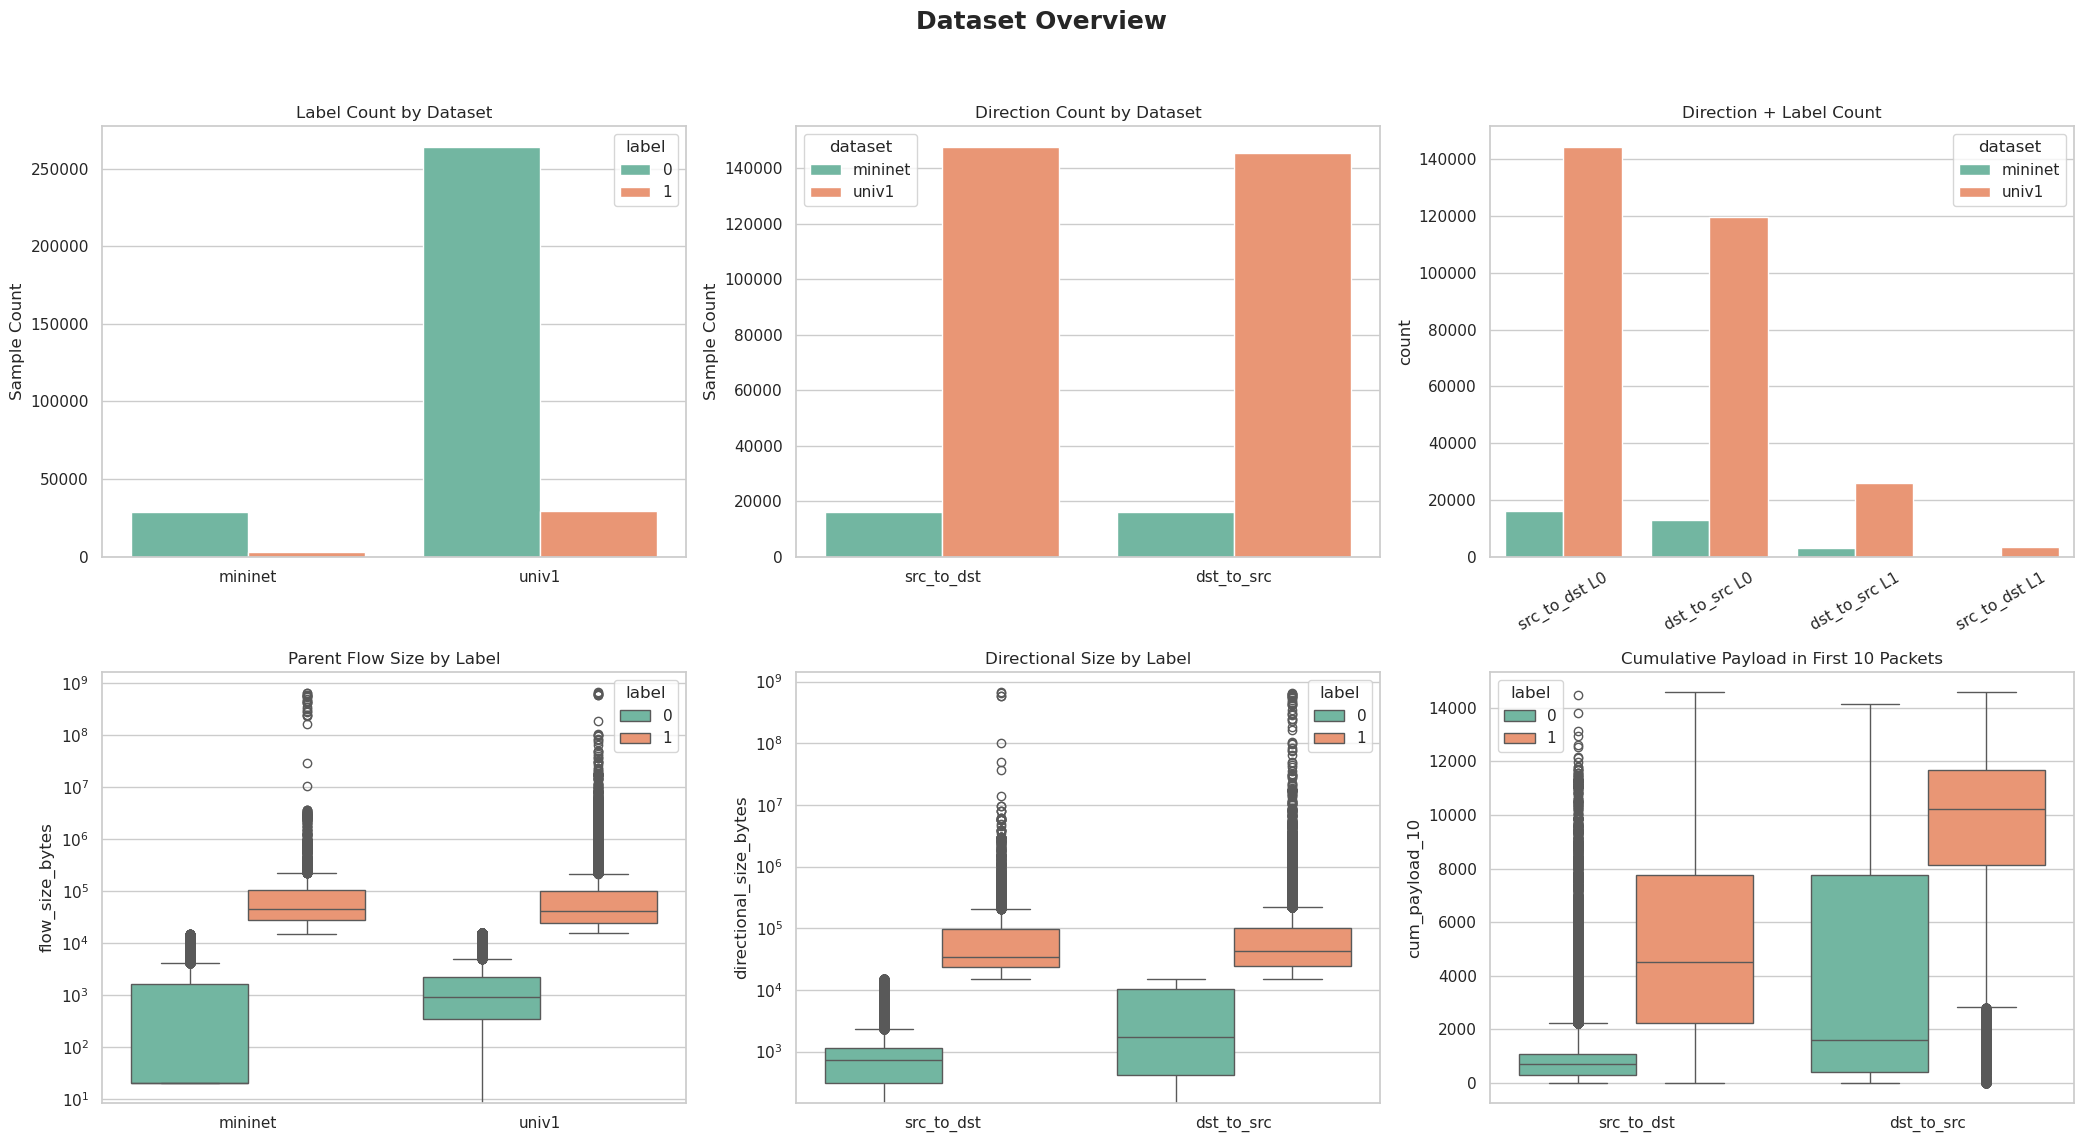

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('Dataset Overview', fontsize=18, fontweight='bold')

sns.countplot(x='dataset', hue='label', data=all_df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Label Count by Dataset')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Sample Count')

sns.countplot(x='direction', hue='dataset', data=all_df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Direction Count by Dataset')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Sample Count')

sns.countplot(x='direction_label', hue='dataset', data=all_df, ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Direction + Label Count')
axes[0, 2].set_xlabel('')
axes[0, 2].tick_params(axis='x', rotation=30)

sns.boxplot(x='dataset', y='flow_size_bytes', hue='label', data=all_df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Parent Flow Size by Label')
axes[1, 0].set_xlabel('')

sns.boxplot(x='direction', y='directional_size_bytes', hue='label', data=all_df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Directional Size by Label')
axes[1, 1].set_xlabel('')

sns.boxplot(x='direction', y='cum_payload_10', hue='label', data=all_df, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Cumulative Payload in First 10 Packets')
axes[1, 2].set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


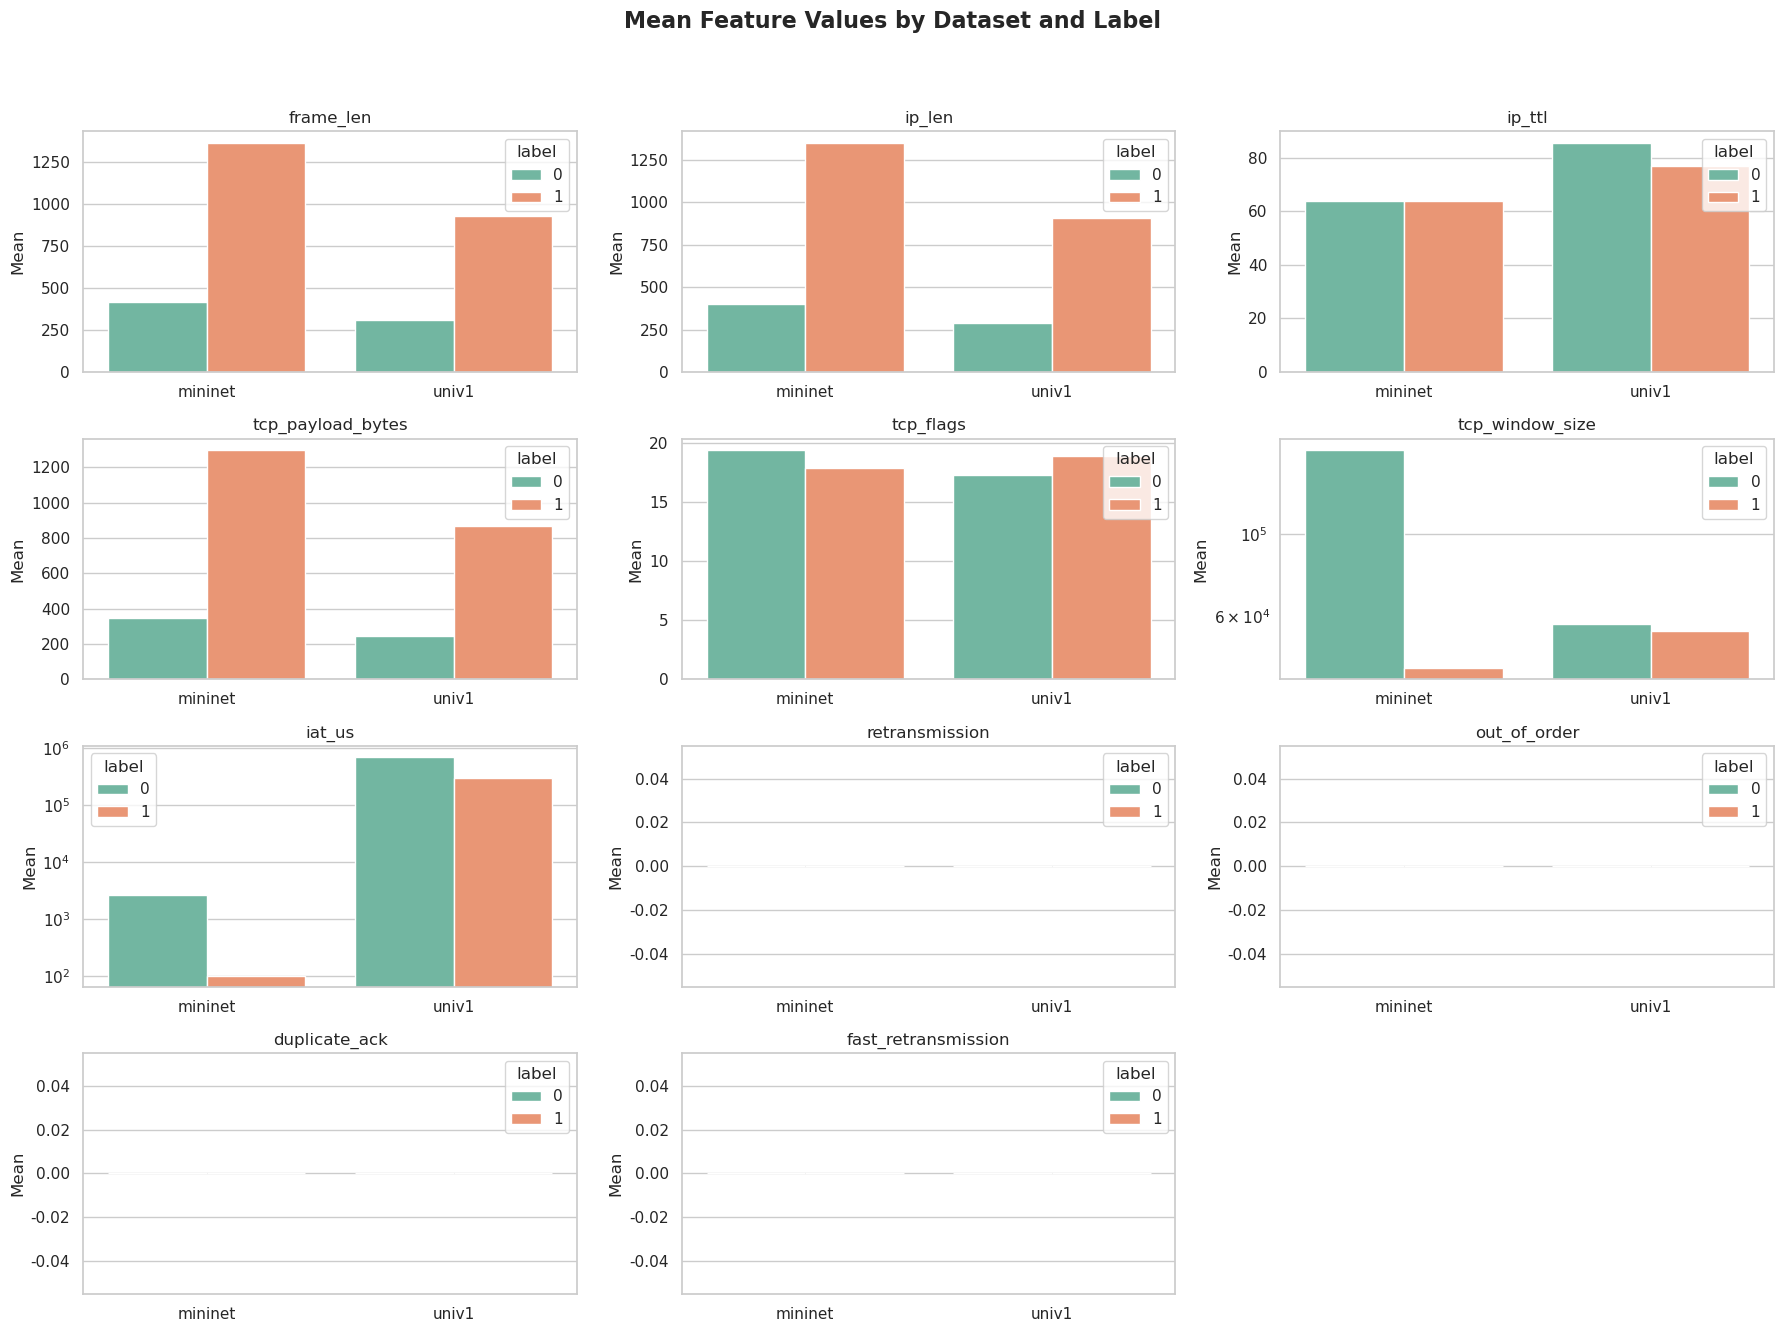

In [5]:
feature_mean_cols = [f'{name}_mean' for name in FEATURE_NAMES]
feature_compare = all_df.groupby(['dataset', 'label'])[feature_mean_cols].mean().reset_index()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Mean Feature Values by Dataset and Label', fontsize=16, fontweight='bold')

for i, feature_name in enumerate(FEATURE_NAMES):
    ax = axes[i // 3, i % 3]
    sns.barplot(
        x='dataset',
        y=f'{feature_name}_mean',
        hue='label',
        data=feature_compare,
        ax=ax,
        palette='Set2',
    )
    if feature_name in ['iat_us', 'tcp_window_size']:
        ax.set_yscale('log')
    ax.set_title(feature_name)
    ax.set_xlabel('')
    ax.set_ylabel('Mean')

axes[3, 2].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


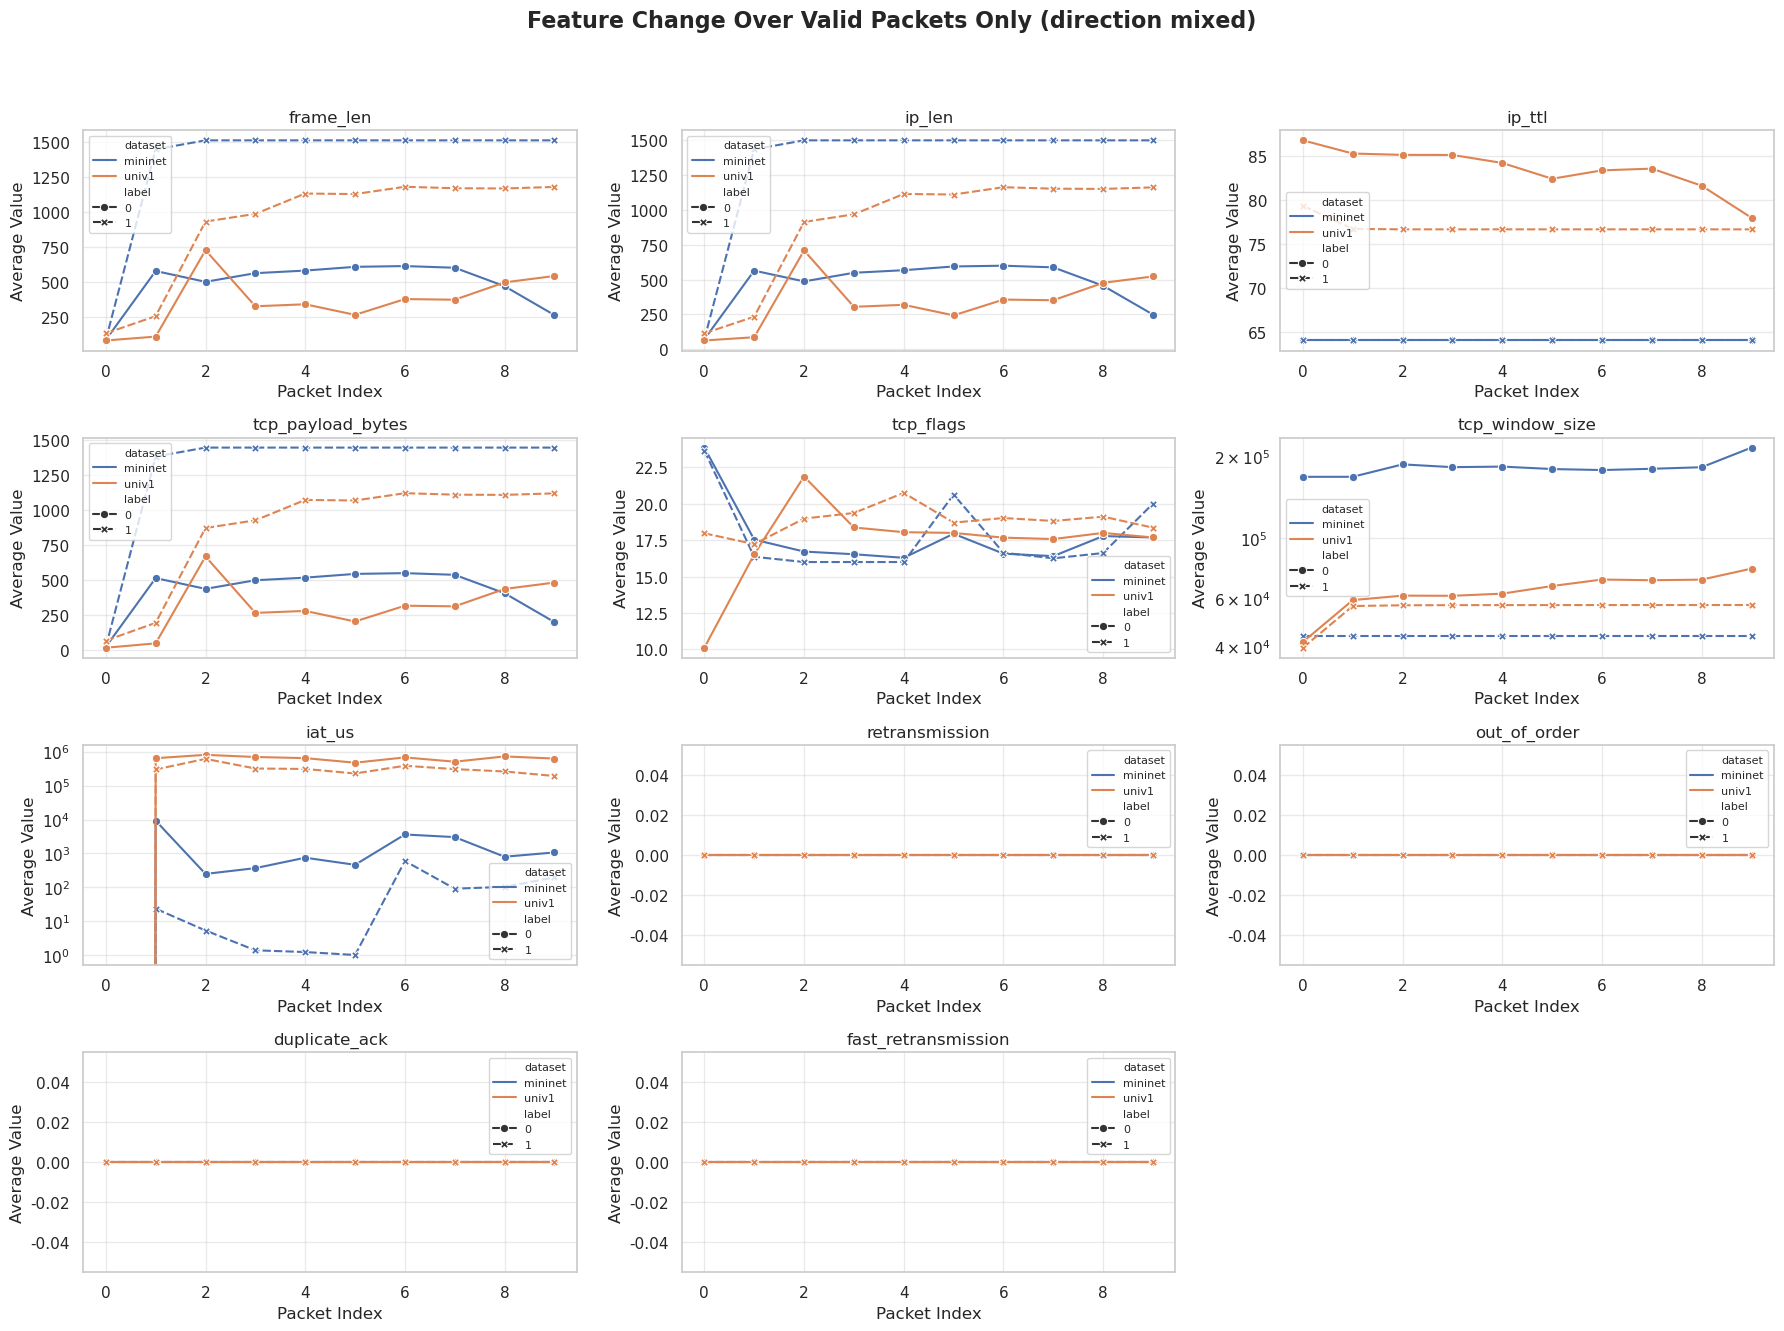

direction mix by dataset/label:
dataset  label  direction 
mininet  0      dst_to_src     12799
                src_to_dst     16000
         1      dst_to_src      3201
univ1    0      dst_to_src    119541
                src_to_dst    144425
         1      dst_to_src     25982
                src_to_dst      3349
dtype: int64


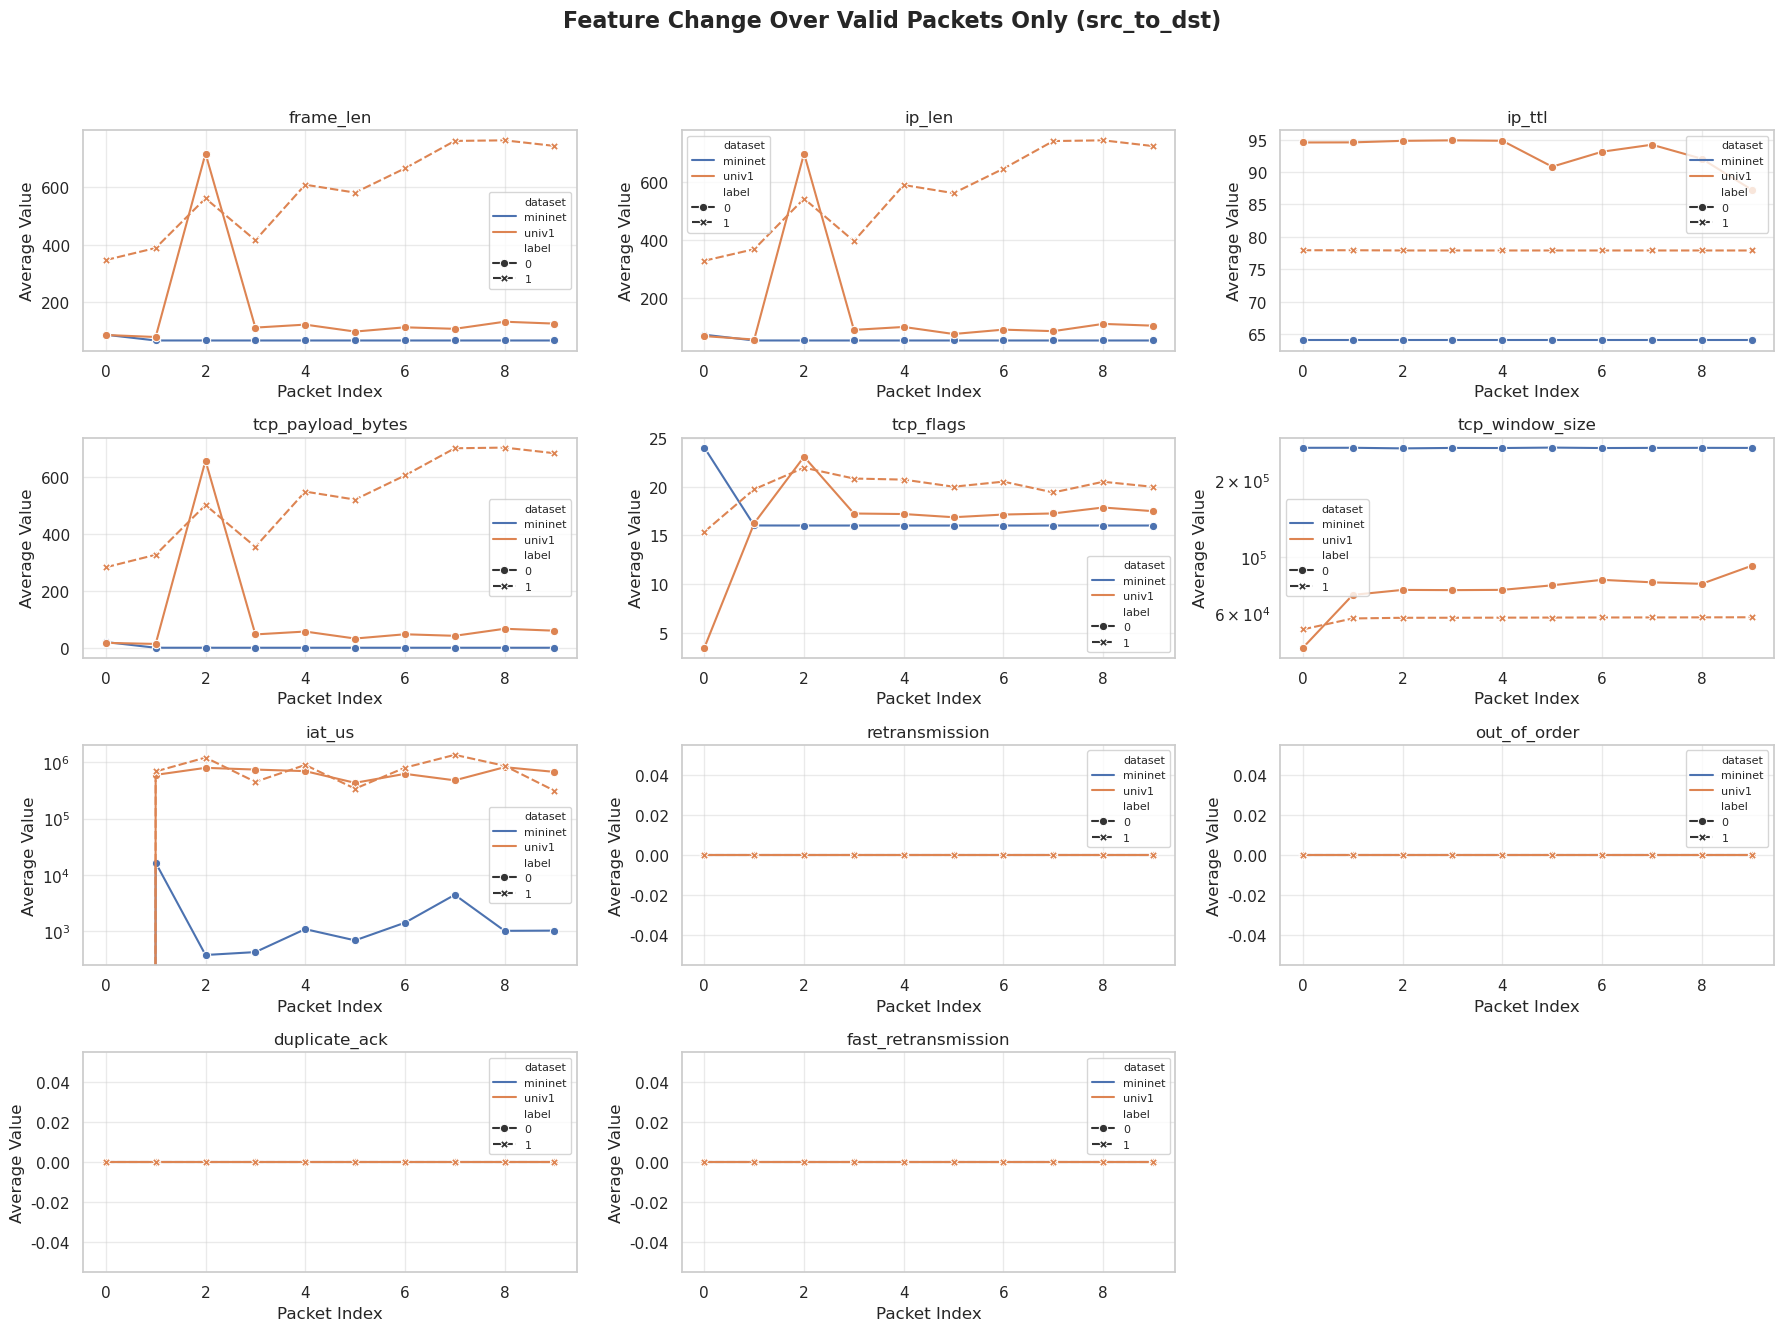

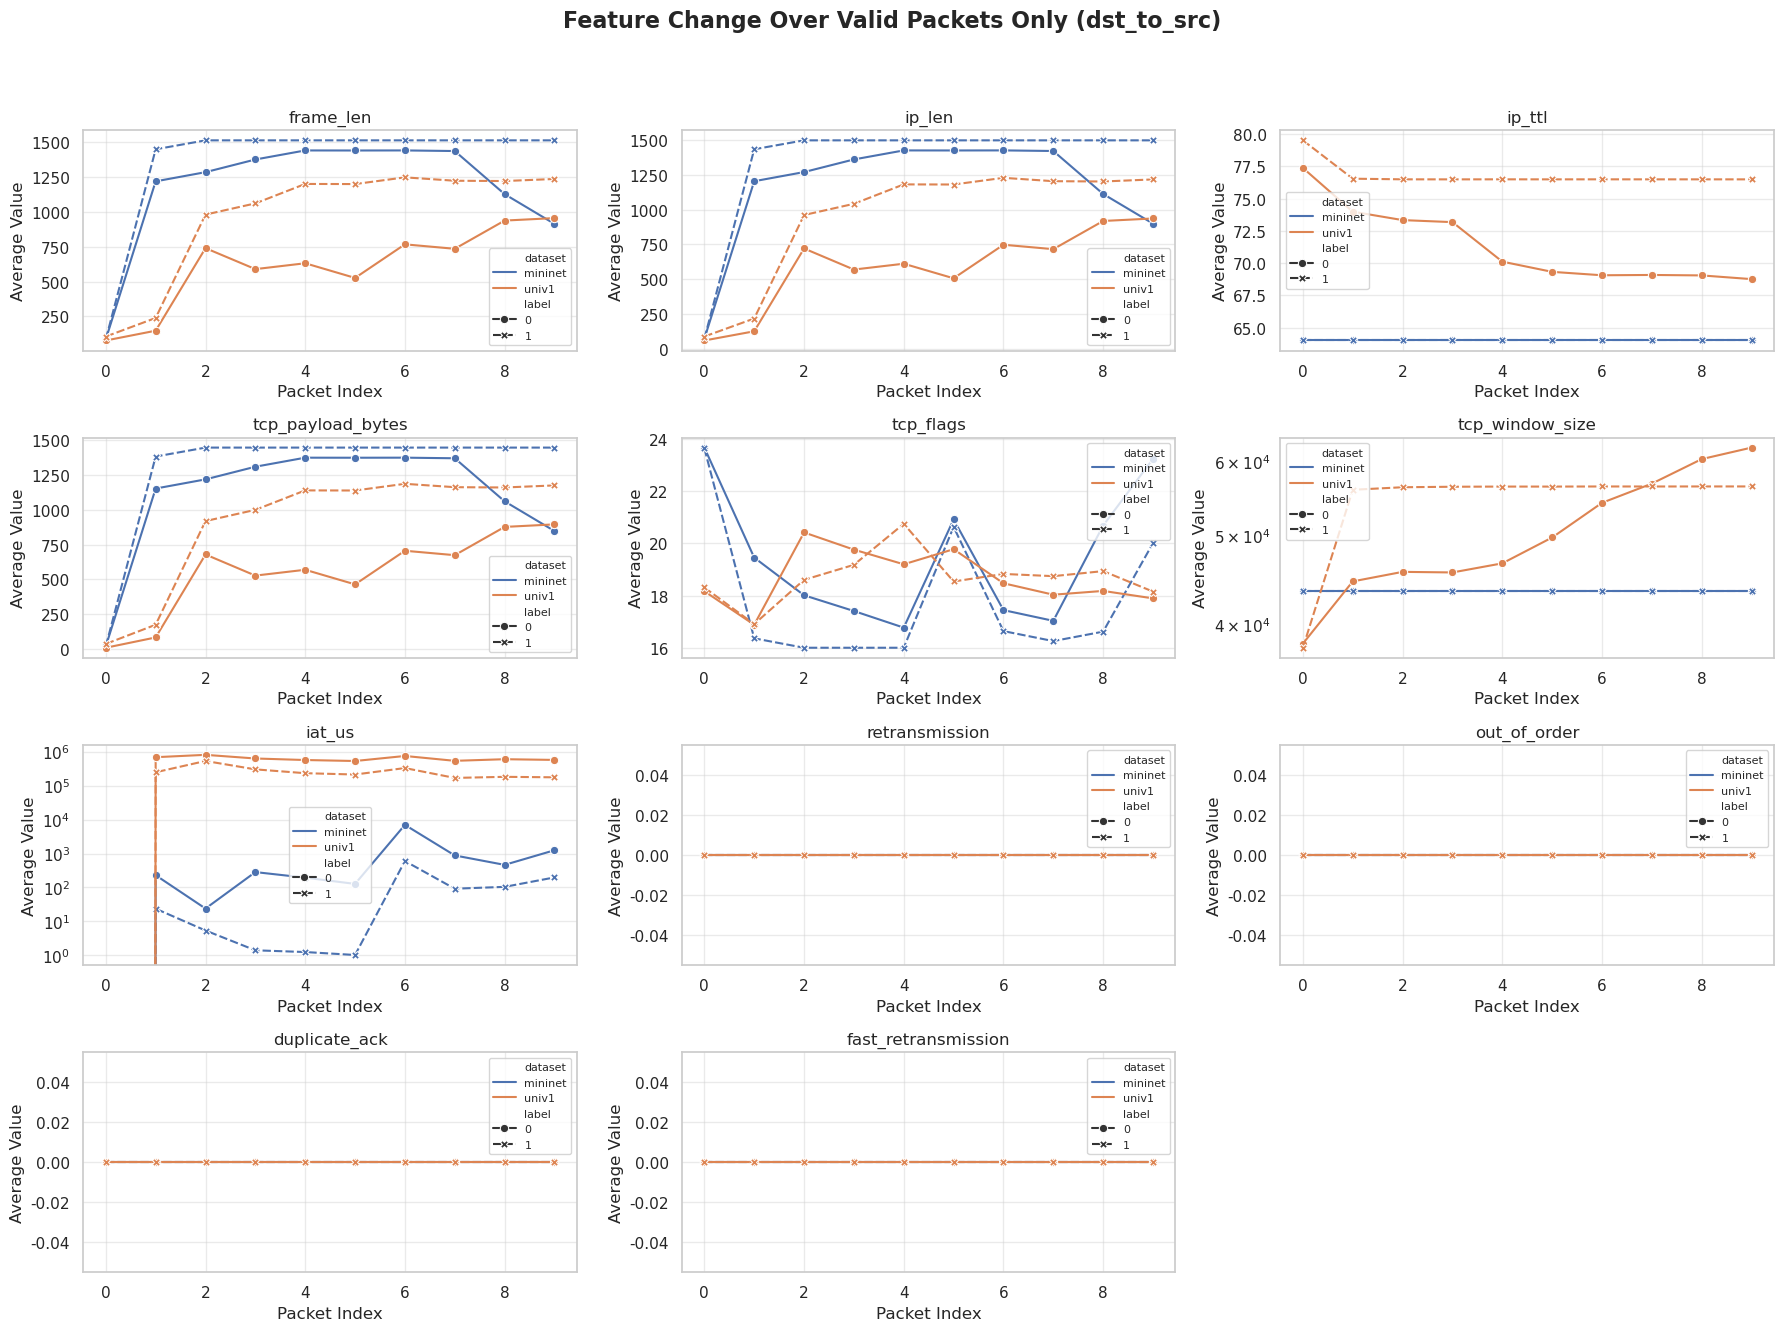

In [6]:
# Padding row를 제외하고, 실제 관측된 packet만 이용해 packet index별 feature 변화를 봅니다.
avg_mixed_by_label = valid_packet_df.groupby(['dataset', 'label', 'packet_index'])[FEATURE_NAMES].mean().reset_index()

fig, axes = plt.subplots(4, 3, figsize=(18, 14))
fig.suptitle('Feature Change Over Valid Packets Only (direction mixed)', fontsize=16, fontweight='bold')

for i, feature_name in enumerate(FEATURE_NAMES):
    ax = axes[i // 3, i % 3]
    sns.lineplot(
        data=avg_mixed_by_label,
        x='packet_index',
        y=feature_name,
        hue='dataset',
        style='label',
        markers=True,
        dashes=True,
        ax=ax,
    )
    if feature_name in ['iat_us', 'tcp_window_size']:
        ax.set_yscale('log')
    ax.set_title(feature_name)
    ax.set_xlabel('Packet Index')
    ax.set_ylabel('Average Value')
    ax.grid(True, alpha=0.4)
    ax.legend(fontsize=8)

axes[3, 2].axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('direction mix by dataset/label:')
print(all_df.groupby(['dataset', 'label', 'direction']).size())

# 필요할 때 순수 direction별 차이도 확인할 수 있도록 별도 plot은 남겨둡니다.
avg_by_direction_label = valid_packet_df.groupby(['dataset', 'direction', 'label', 'packet_index'])[FEATURE_NAMES].mean().reset_index()

for direction in ['src_to_dst', 'dst_to_src']:
    fig, axes = plt.subplots(4, 3, figsize=(18, 14))
    fig.suptitle(f'Feature Change Over Valid Packets Only ({direction})', fontsize=16, fontweight='bold')

    for i, feature_name in enumerate(FEATURE_NAMES):
        ax = axes[i // 3, i % 3]
        subset = avg_by_direction_label[avg_by_direction_label['direction'] == direction]
        sns.lineplot(
            data=subset,
            x='packet_index',
            y=feature_name,
            hue='dataset',
            style='label',
            markers=True,
            dashes=True,
            ax=ax,
        )
        if feature_name in ['iat_us', 'tcp_window_size']:
            ax.set_yscale('log')
        ax.set_title(feature_name)
        ax.set_xlabel('Packet Index')
        ax.set_ylabel('Average Value')
        ax.grid(True, alpha=0.4)
        ax.legend(fontsize=8)

    axes[3, 2].axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


In [6]:
summary = all_df.groupby(['dataset', 'label'])[['flow_size_bytes', 'directional_size_bytes', 'x_mean'] + feature_mean_cols].agg(['mean', 'median', 'std'])
summary


flow_size_bytes                         directional_size_bytes  \
                         mean    median           std                   mean   
dataset label                                                                  
mininet 0        3.316073e+04   21759.0  3.234116e+04           1.717348e+04   
        1        1.719428e+07  356600.0  8.746192e+07           8.597151e+06   
univ1   0        2.000223e+04   11579.0  1.882969e+04           1.237436e+04   
        1        1.164625e+06  177836.0  1.822301e+07           5.982918e+05   

                                            x_mean                \
                median           std          mean        median   
dataset label                                                      
mininet 0         20.0  2.804364e+04  14625.724662   4677.600000   
        1      72204.5  6.244012e+07  14586.550458   4361.477273   
univ1   0      10443.0  1.599224e+04  47539.853138  10983.672727   
        1      99327.0  1.289889e+07  22733.625000   9454.763636   

                             frame_len_mean  ... retransmission_mean  \
                         std           mean  ...                 std   
dataset label                                ...                       
mininet 0       15478.954010     681.685956  ...                 0.0   
        1       15519.706133     715.958957  ...                 0.0   
univ1   0      182483.333128     590.594459  ...                 0.0   
        1      158336.657951     603.616970  ...                 0.0   

              out_of_order_mean             duplicate_ack_mean              \
                           mean median  std               mean median  std   
dataset label                                                                
mininet 0                   0.0    0.0  0.0                0.0    0.0  0.0   
        1                   0.0    0.0  0.0                0.0    0.0  0.0   
univ1   0                   0.0    0.0  0.0                0.0    0.0  0.0   
        1                   0.0    0.0  0.0                0.0    0.0  0.0   

              fast_retransmission_mean              
                                  mean median  std  
dataset label                                       
mininet 0                          0.0    0.0  0.0  
        1                          0.0    0.0  0.0  
univ1   0                          0.0    0.0  0.0  
        1                          0.0    0.0  0.0  

[4 rows x 42 columns]

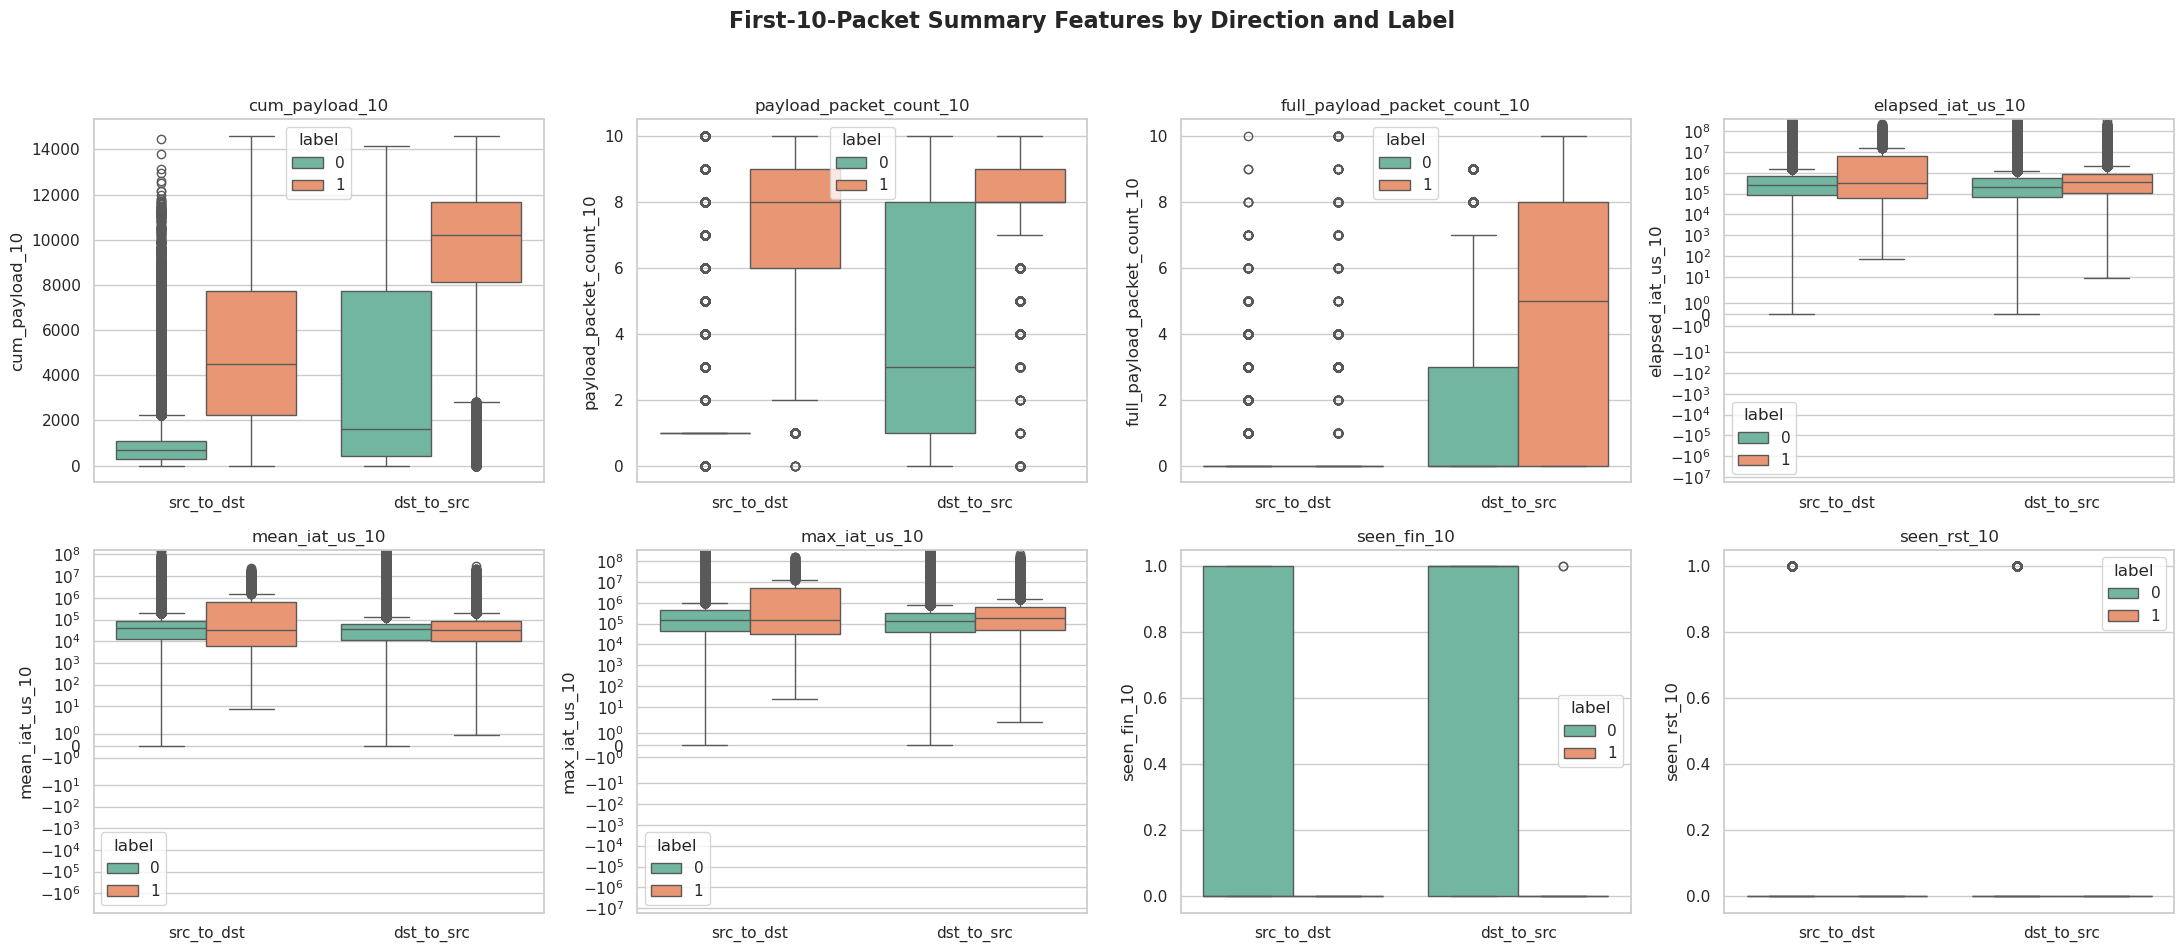

cum_payload_10                                  \
                                  count          mean   median      min   
dataset direction  label                                                  
mininet dst_to_src 0              12799   4760.394562   2040.0     21.0   
                   1               3201  12986.860356  13052.0  11604.0   
        src_to_dst 0              16000     20.018750     20.0     20.0   
univ1   dst_to_src 0             119541   3461.163726   1583.0      0.0   
                   1              25982   9098.980294   9883.0      0.0   
        src_to_dst 0             144425    901.207263    787.0      0.0   
                   1               3349   5233.045984   4507.0      0.0   

                                  payload_packet_count_10                   \
                              max                   count      mean median   
dataset direction  label                                                     
mininet dst_to_src 0      13052.0                   12799  4.763106    3.0   
                   1      13052.0                    3201  9.955014   10.0   
        src_to_dst 0         60.0                   16000  1.000938    1.0   
univ1   dst_to_src 0      14135.0                  119541  4.009018    3.0   
                   1      14600.0                   25982  7.891579    8.0   
        src_to_dst 0      14480.0                  144425  1.645733    1.0   
                   1      14600.0                    3349  7.594804    8.0   

                                  ... flow_size_bytes                         \
                         min max  ...           count          mean   median   
dataset direction  label          ...                                          
mininet dst_to_src 0       2  10  ...           12799  4.775085e+03   2040.0   
                   1       9  10  ...            3201  3.128782e+06  44214.0   
        src_to_dst 0       1   3  ...           16000  2.006500e+01     20.0   
univ1   dst_to_src 0       0  10  ...          119541  4.452944e+03   1662.0   
                   1       0  10  ...           25982  2.451448e+05  42294.0   
        src_to_dst 0       0  10  ...          144425  1.159519e+03    812.0   
                   1       0  10  ...            3349  9.853794e+05  33673.0   

                                           directional_size_bytes  \
                            min        max                  count   
dataset direction  label                                            
mininet dst_to_src 0         21      14706                  12799   
                   1      14754  646328655                   3201   
        src_to_dst 0         20         60                  16000   
univ1   dst_to_src 0          0      15269                 119541   
                   1      15271  627037592                  25982   
        src_to_dst 0          0      15268                 144425   
                   1      15270  682769160                   3349   

                                                                   
                                  mean   median    min        max  
dataset direction  label                                           
mininet dst_to_src 0      4.775085e+03   2040.0     21      14706  
                   1      3.128782e+06  44214.0  14754  646328655  
        src_to_dst 0      2.006500e+01     20.0     20         60  
univ1   dst_to_src 0      4.452944e+03   1662.0      0      15269  
                   1      2.451448e+05  42294.0  15271  627037592  
        src_to_dst 0      1.159519e+03    812.0      0      15268  
                   1      9.853794e+05  33673.0  15270  682769160  

[7 rows x 50 columns]

In [7]:
# Direction별 초기 10패킷 요약 feature 비교
summary_features = [
    'cum_payload_10',
    'payload_packet_count_10',
    'full_payload_packet_count_10',
    'elapsed_iat_us_10',
    'mean_iat_us_10',
    'max_iat_us_10',
    'seen_fin_10',
    'seen_rst_10',
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('First-10-Packet Summary Features by Direction and Label', fontsize=16, fontweight='bold')

for i, feature in enumerate(summary_features):
    ax = axes[i // 4, i % 4]
    sns.boxplot(
        data=all_df,
        x='direction',
        y=feature,
        hue='label',
        ax=ax,
        palette='Set2',
    )
    if feature in ['elapsed_iat_us_10', 'mean_iat_us_10', 'max_iat_us_10']:
        ax.set_yscale('symlog')
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

display(all_df.groupby(['dataset', 'direction', 'label'])[summary_features + ['flow_size_bytes', 'directional_size_bytes']].agg(['count', 'mean', 'median', 'min', 'max']))


In [8]:
# Mininet에서 같은 valid payload/flags 패턴이 label 양쪽에 얼마나 섞이는지 확인
pattern_rows = []
for _, row in mininet_df.iterrows():
    packets = mininet_packet_df[mininet_packet_df['row_id'] == row['row_id']].sort_values('packet_index')
    pattern = tuple(zip(packets['tcp_payload_bytes'].astype(int), packets['tcp_flags'].astype(int)))
    pattern_rows.append({
        'row_id': row['row_id'],
        'direction': row['direction'],
        'seq_len': row['seq_len'],
        'label': row['label'],
        'pattern': pattern,
    })

pattern_df = pd.DataFrame(pattern_rows)
pattern_summary = (
    pattern_df
    .groupby(['direction', 'seq_len', 'pattern'])
    .agg(count=('label', 'size'), label1=('label', 'sum'))
    .reset_index()
)
pattern_summary['label1_ratio'] = pattern_summary['label1'] / pattern_summary['count']

print('Top repeated valid payload/flags patterns in Mininet:')
display(pattern_summary.sort_values('count', ascending=False).head(20))

print('Patterns appearing in both labels are ambiguous for feature-only classification:')
ambiguous_patterns = pattern_summary[(pattern_summary['label1_ratio'] > 0) & (pattern_summary['label1_ratio'] < 1)]
display(ambiguous_patterns.sort_values('count', ascending=False).head(20))


Top repeated valid payload/flags patterns in Mininet:


,direction,seq_len,pattern,count,label1,label1_ratio
7066,src_to_dst,10,"((20, 24), (0, 16), (0, 16), (0, 16), (0, 16),...",5011,0,0.000000
7053,src_to_dst,3,"((20, 24), (0, 16), (0, 16))",4347,0,0.000000
7052,src_to_dst,2,"((20, 24), (0, 16))",1936,0,0.000000
7051,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",1509,1421,0.941683
7055,src_to_dst,4,"((20, 24), (0, 16), (0, 16), (0, 16))",1438,0,0.000000
7057,src_to_dst,5,"((20, 24), (0, 16), (0, 16), (0, 16), (0, 16))",1324,0,0.000000
7059,src_to_dst,6,"((20, 24), (0, 16), (0, 16), (0, 16), (0, 16),...",751,0,0.000000
6299,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",595,562,0.944538
7050,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",454,431,0.949339
7061,src_to_dst,7,"((20, 24), (0, 16), (0, 16), (0, 16), (0, 16),...",430,0,0.000000


Patterns appearing in both labels are ambiguous for feature-only classification:


,direction,seq_len,pattern,count,label1,label1_ratio
7051,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",1509,1421,0.941683
6299,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",595,562,0.944538
7050,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",454,431,0.949339
6378,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",259,247,0.953668
6040,dst_to_src,10,"((0, 16), (20, 24), (1448, 16), (1448, 16), (1...",211,144,0.682464
6300,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",191,183,0.958115
6456,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",116,111,0.956897
6409,dst_to_src,10,"((20, 24), (1448, 16), (1448, 16), (1448, 16),...",107,102,0.953271
